In [366]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.interpolate import interp1d



anchor_points_ratio = 0.2

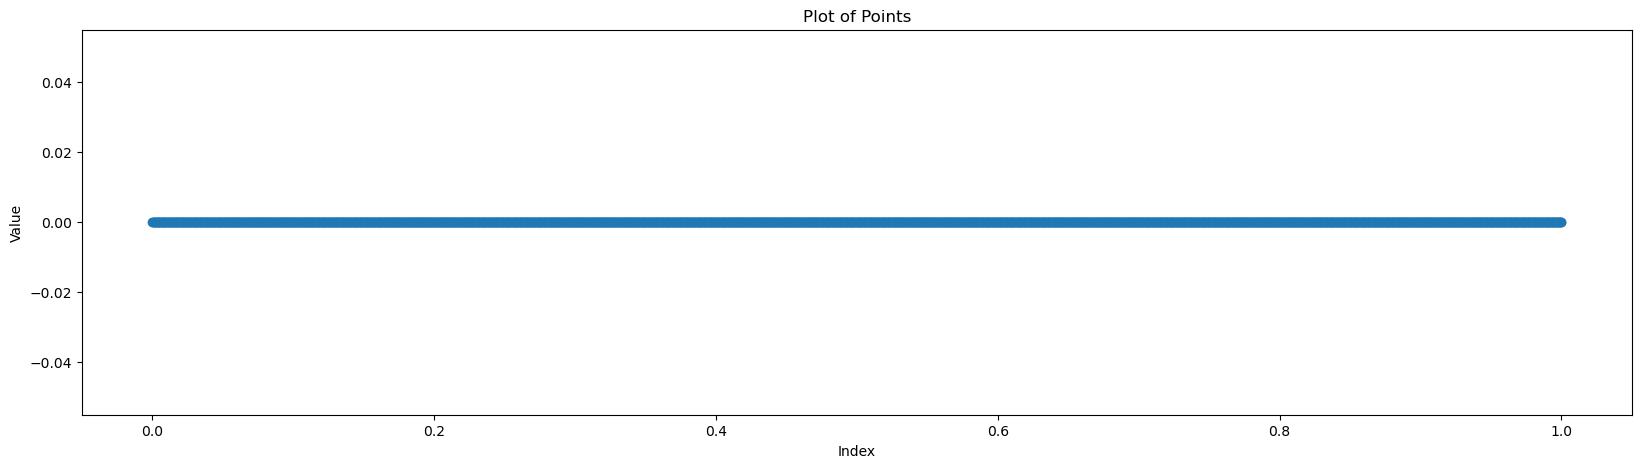

In [367]:
def get_non_uniform_sampling(smooth_signal, free_points_x, anchor_points_x, manifold_x, length):

    non_uniform_sampling = np.random.choice(free_points_x, int((1 - anchor_points_ratio) * length), replace=False)
    non_uniform_sampling.sort()

    non_uniform_sampling = np.concatenate((anchor_points_x, non_uniform_sampling))
    non_uniform_sampling.sort()

    non_uniform_sampled_manifold_x = np.searchsorted(manifold_x, non_uniform_sampling)
    non_uniform_sampled_manifold_y = smooth_signal[non_uniform_sampled_manifold_x]

    return non_uniform_sampling, non_uniform_sampled_manifold_y


signal_length = 100

manifold_x = np.linspace(0, 1, signal_length * 20)

plt.figure(figsize=(20, 5))  # Adjust the width and height as needed
plt.scatter(manifold_x, np.zeros_like(manifold_x))
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Plot of Points')
plt.show()

[0.         0.05263158 0.10526316 0.15789474 0.21052632 0.26315789
 0.31578947 0.36842105 0.42105263 0.47368421 0.52631579 0.57894737
 0.63157895 0.68421053 0.73684211 0.78947368 0.84210526 0.89473684
 0.94736842 1.        ]


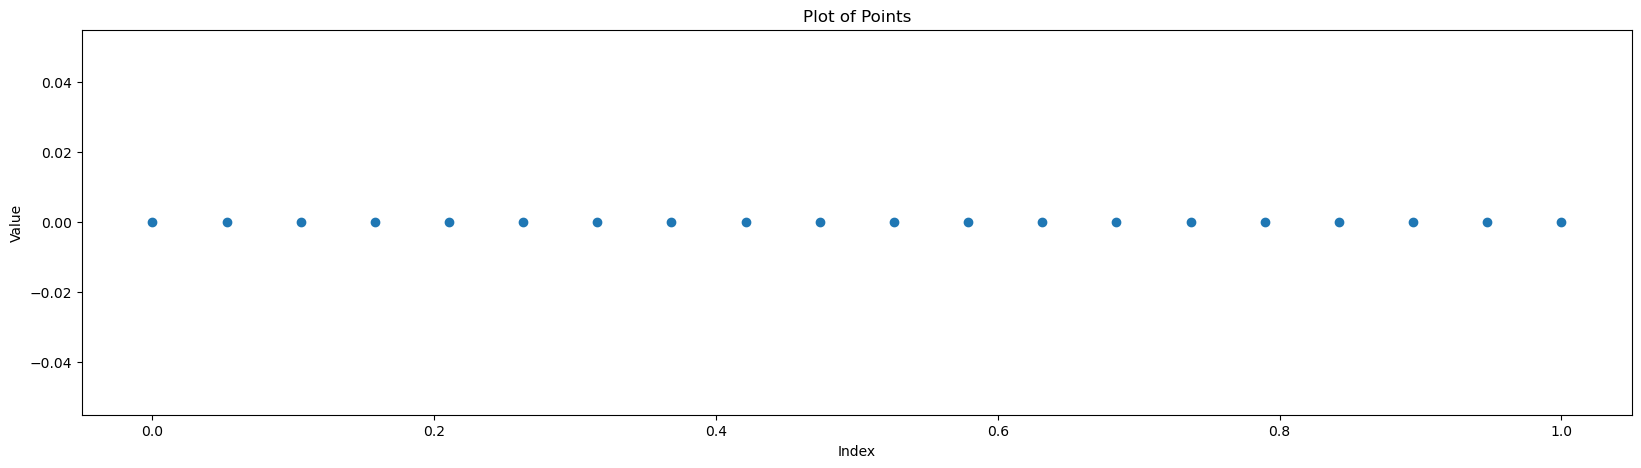

In [368]:
anchor_points_x = np.linspace(manifold_x[0], manifold_x[-1], int(signal_length * anchor_points_ratio))
anchor_points_x.sort()
print(anchor_points_x)
plt.figure(figsize=(20, 5))  # Adjust the width and height as needed
plt.scatter(anchor_points_x, np.zeros_like(anchor_points_x))
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Plot of Points')
plt.show()

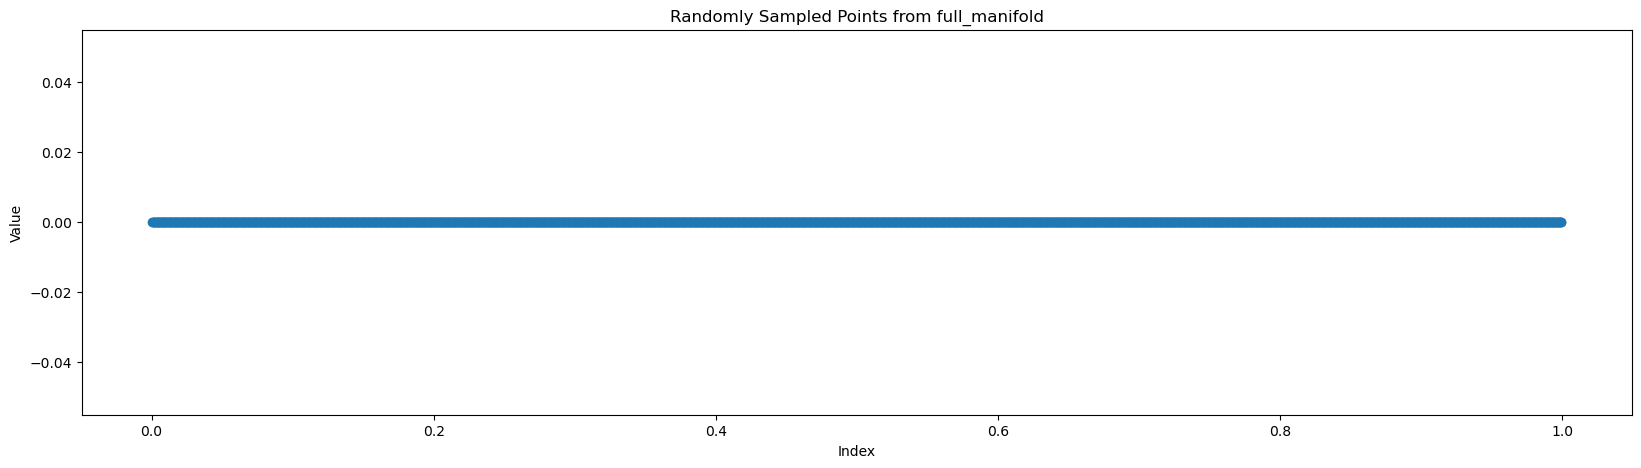

In [369]:
# Find points in full_manifold that are not in sampled_points
free_points_x = np.setdiff1d(manifold_x, anchor_points_x)

plt.figure(figsize=(20, 5))  # Adjust the width and height as needed
plt.scatter(free_points_x, np.zeros_like(free_points_x), marker='o')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Randomly Sampled Points from full_manifold')
plt.show()

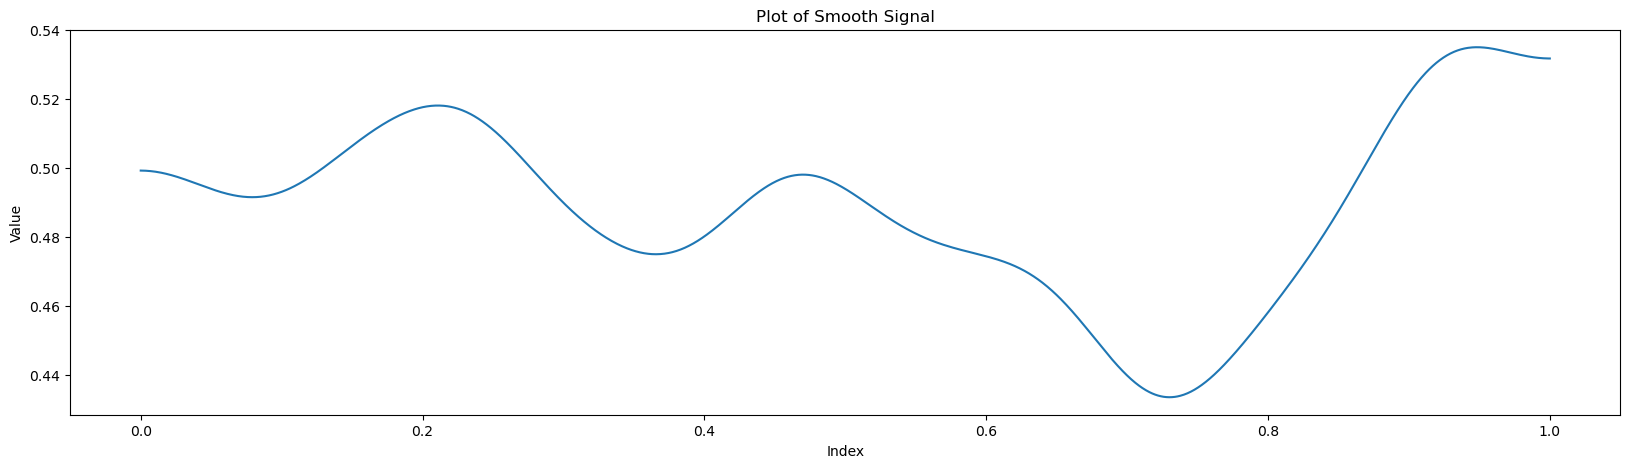

In [370]:
# Set up the random number generator and create the signal
rng = np.random.default_rng()
noise = rng.random(len(manifold_x))

# Choose a smoothing factor (sigma)
smoothing_factor = rng.uniform(low=50, high=150)

# Apply 1D Gaussian smoothing
manifold_y = gaussian_filter1d(noise, smoothing_factor)

# Plot the result
plt.figure(figsize=(20, 5))
plt.plot(manifold_x, manifold_y)
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Plot of Smooth Signal')
plt.show()

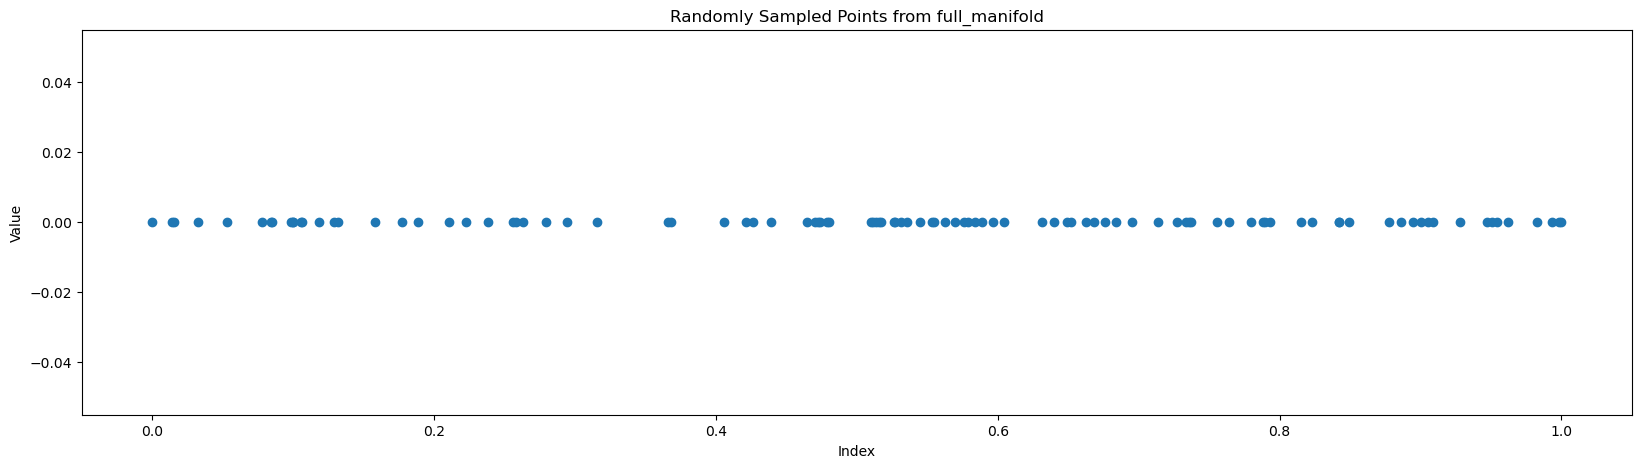

In [371]:
non_uniform_x, non_uniform_y = get_non_uniform_sampling(manifold_y, free_points_x, anchor_points_x, manifold_x, signal_length)

plt.figure(figsize=(20, 5))  # Adjust the width and height as needed
plt.scatter(non_uniform_x, np.zeros_like(non_uniform_x), marker='o')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Randomly Sampled Points from full_manifold')
plt.show()

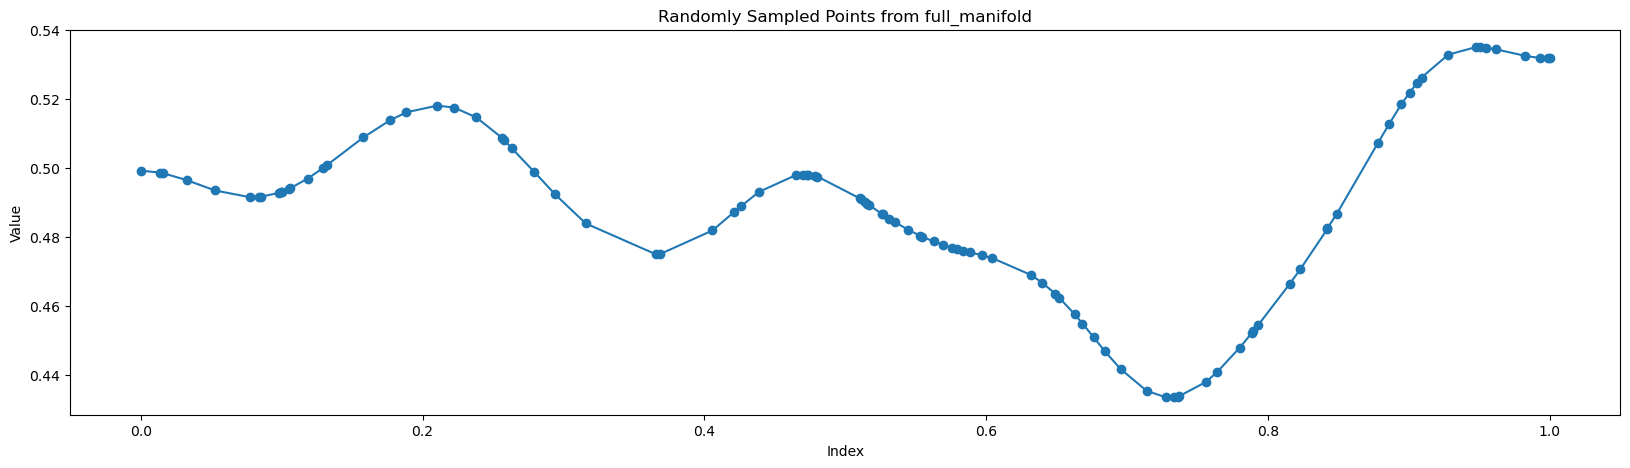

In [372]:
plt.figure(figsize=(20, 5))  # Adjust the width and height as needed
plt.plot(non_uniform_x, non_uniform_y, marker='o', linestyle='-')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Randomly Sampled Points from full_manifold')
plt.show()

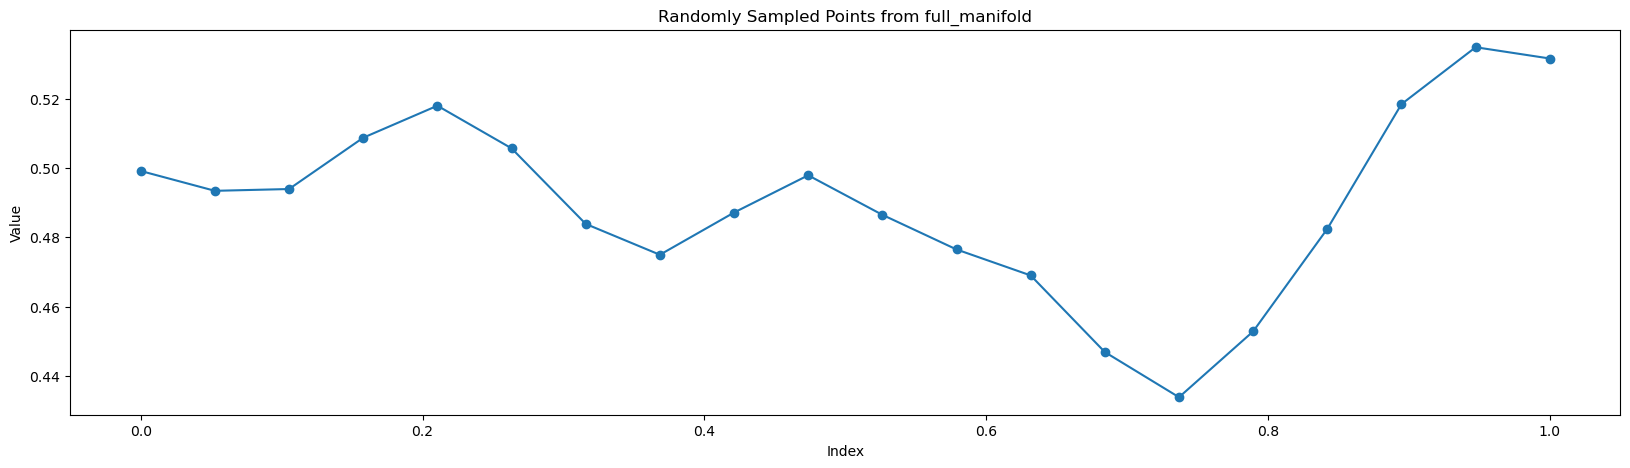

In [373]:
anchor_indices = np.searchsorted(non_uniform_x, anchor_points_x)
anchor_points_y = non_uniform_y[anchor_indices]

plt.figure(figsize=(20, 5))  # Adjust the width and height as needed
plt.plot(anchor_points_x, anchor_points_y, marker='o', linestyle='-')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Randomly Sampled Points from full_manifold')
plt.show()
